In [197]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [198]:
def plot_dist_pie(df, col, title=None):
    counts = df[col].value_counts(dropna=False)
    labels = [str(x) for x in counts.index]
    plt.figure(figsize=(4, 4))
    plt.pie(
        counts,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p/100.*sum(counts)))})',
        startangle=140
    )
    plt.title(title or f"{col} distribution")
    plt.tight_layout()
    plt.show()

In [199]:
SAMPLE_DIR = Path("samples/ymyl_29000/res_20250723_n100")

# Queries
queries_df = pd.read_csv(SAMPLE_DIR.parent / "queries_ymyl_29000.csv")

# AI overviews
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
responses_df['references'] = responses_df['references'].apply(json.loads)
responses_df['organic_results'] = responses_df['organic_results'].apply(json.loads)

# Document pool
classified_urls_df = pd.read_csv(SAMPLE_DIR / "__classified_urls.csv")
unclassified_urls_df = pd.read_csv(SAMPLE_DIR / "__unclassified_urls.csv")

In [200]:
ai_count = (classified_urls_df['ai_class'] == 'AI').sum()
human_count = (classified_urls_df['ai_class'] == 'Human').sum()

In [201]:
aio_query_ids = set(responses_df['query_id'])
aio_queries_df = queries_df[queries_df['query_id'].isin(aio_query_ids)]

In [202]:
print('Total queries'.ljust(15) + ':', len(queries_df))
print('Total AIOs'.ljust(15) + ':', len(responses_df))
print('Total docs'.ljust(15) + ':', len(classified_urls_df) + len(unclassified_urls_df))

print('Total class.'.ljust(15) + ':', len(classified_urls_df), f'(AI: {ai_count}, Human: {human_count})')
print('Total unclass.'.ljust(15) + ':', len(unclassified_urls_df))

Total queries  : 29000
Total AIOs     : 2597
Total docs     : 214724
Total class.   : 167856 (AI: 16973, Human: 150883)
Total unclass. : 46868


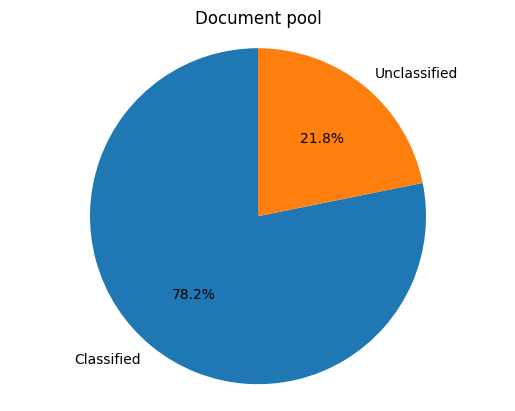

In [203]:
len_classified = len(classified_urls_df)
len_unclassified = len(unclassified_urls_df)

labels = ["Classified", "Unclassified"]
sizes = [len_classified, len_unclassified]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Document pool")
plt.axis('equal')  # Equal aspect ratio makes the pie a circle
plt.show()

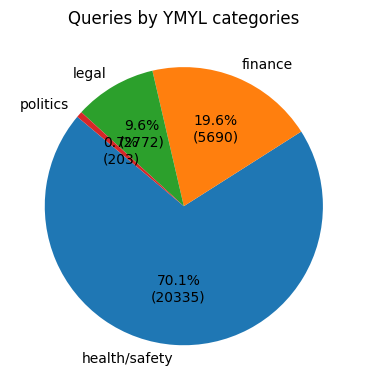

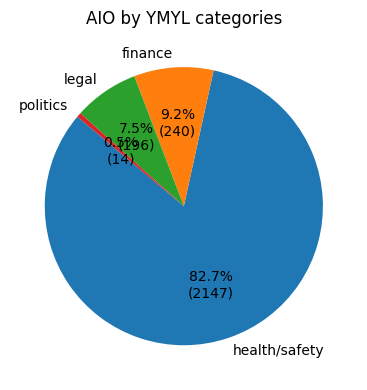

In [204]:
plot_dist_pie(queries_df, 'ymyl_category', 'Queries by YMYL categories')
plot_dist_pie(aio_queries_df, 'ymyl_category', 'AIO by YMYL categories')

health/safety queries: 20335, AIOs: 2147, AIO rate: 10.56%
finance queries: 5690, AIOs: 240, AIO rate: 4.22%
legal queries: 2772, AIOs: 196, AIO rate: 7.07%
politics queries: 203, AIOs: 14, AIO rate: 6.90%


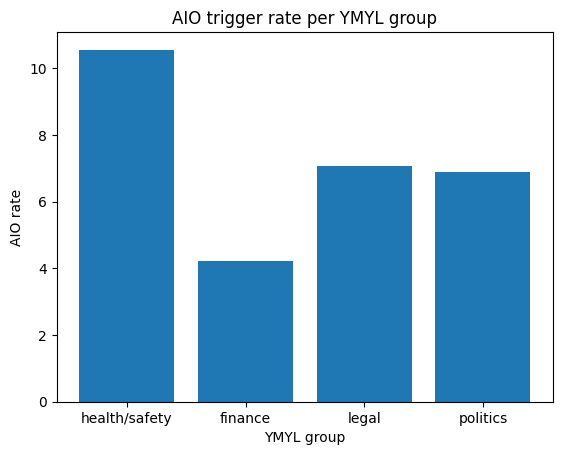

In [205]:
cats = []
rates = []

for cat in queries_df['ymyl_category'].unique():
    query_count = len(queries_df[queries_df['ymyl_category'] == cat])
    aio_count = len(aio_queries_df[aio_queries_df['ymyl_category'] == cat])
    aio_rate = aio_count / query_count * 100
    print(cat, f'queries: {query_count}, AIOs: {aio_count}, AIO rate: {aio_rate:.2f}%')
    cats.append(cat)
    rates.append(aio_rate)

plt.bar(cats, rates)
plt.xlabel("YMYL group")
plt.ylabel("AIO rate")
plt.title("AIO trigger rate per YMYL group")
plt.show()

# Blog post 1 graphics

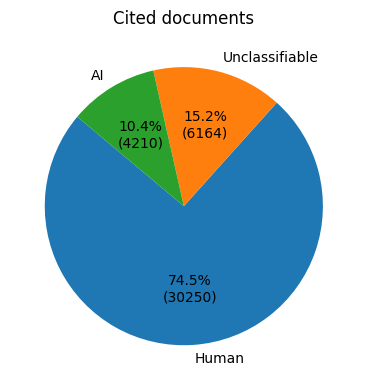

In [206]:
citations_df = (
    responses_df
    .explode('references')
    # .drop_duplicates(subset=['references'])
    .rename(columns={'references': 'url'})
    .assign(organic=lambda df: df.apply(
        lambda row: row['url'] in row['organic_results'],
        axis=1
    ))
    [['url', 'organic']]
    .reset_index(drop=True)
    .merge(classified_urls_df[['url', 'ai_class']], on='url', how='left')
    .assign(**{'class': lambda df: df['ai_class'].fillna('Unclassifiable')})
    .drop(columns=['ai_class'])
)

plot_dist_pie(citations_df, 'class', 'Cited documents')

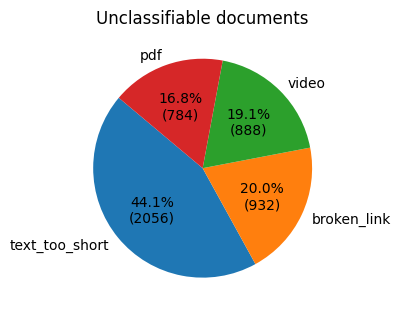

In [207]:
unclassified_citations_df = unclassified_urls_df[
    unclassified_urls_df['url'].isin(
        citations_df.loc[citations_df['class'] == 'Unclassifiable', 'url']
    )
].reset_index(drop=True)

plot_dist_pie(unclassified_citations_df, 'category', 'Unclassifiable documents')

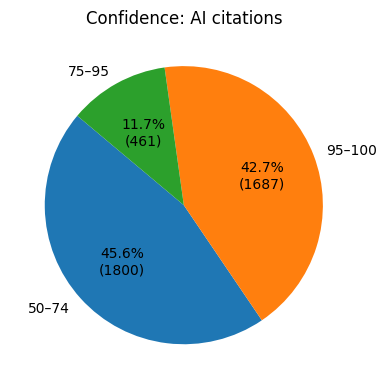

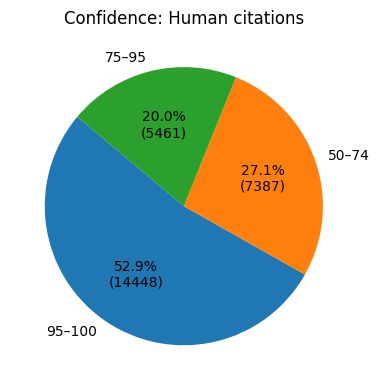

In [208]:
# AI/Human confidence buckets

cited_classified_df = classified_urls_df[
    classified_urls_df['url'].isin(citations_df['url'])
].reset_index(drop=True)

def bucket(conf):
    if conf >= 95:
        return "95–100"
    elif conf >= 75:
        return "75–95"
    elif conf >= 50:
        return "50–74"
    else:
        return "<50"

cited_classified_df["conf_bucket"] = cited_classified_df["confidence"].apply(bucket)

cited_ai_df = cited_classified_df[cited_classified_df["ai_class"] == "AI"]
cited_human_df = cited_classified_df[cited_classified_df["ai_class"] == "Human"]

plot_dist_pie(cited_ai_df, 'conf_bucket', 'Confidence: AI citations')
plot_dist_pie(cited_human_df, 'conf_bucket', 'Confidence: Human citations')

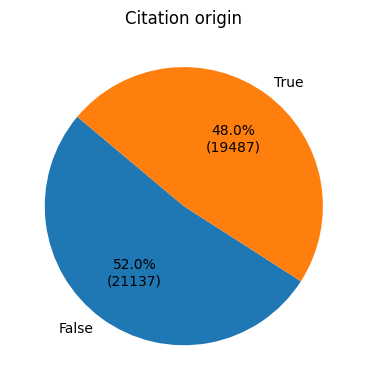

In [211]:
# Organic vs non-organic

plot_dist_pie(citations_df, 'organic', 'Citation origin')